In [1]:
#import relevant libraries
import numpy as np
import seaborn as sns
import random
import math
import cmath
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation

from matplotlib.colors import ListedColormap
from IPython.display import HTML
from collections import defaultdict

In [2]:
#functions

#function generates lattice of 1s and 0s; 1 means there's a firefly there, 0 means it's empty
def lattice(rows, cols, prop_one): #prop_one is proportion of ones
    tot_cells = rows * cols
    num_ones = int(tot_cells * prop_one)

    arr = np.zeros((rows, cols))

    ind_ones = np.random.choice(tot_cells, num_ones, replace = False)
    row_ind = ind_ones // cols
    col_ind = ind_ones % cols

    arr[row_ind, col_ind] = 1

    return arr

#function generates list of firefly phases between 0 and 2pi 
def phase_list(num_ff):
    phases = []
    while len(phases) < num_ff:
        phase = random.uniform(0, 2 * math.pi)
        if phase != 0 and phase != 2 * math.pi:
            phases.append(phase)
    return phases

#function assigns non-empty lattice positions to firefly phases from list
def phase_arr(positions, phases):
    phase_array = np.zeros_like(positions)
    occ_indices = np.argwhere(positions) #list of indices with non-zero entries

    count = 0

    for i, j in occ_indices:
        phase_array[i, j] = phases[count]
        count = count + 1
    return phase_array          

def strat_arr(positions, propC):
    total_nonzero = np.count_nonzero(positions)
    num_coop = int(total_nonzero * propC)
    num_def = total_nonzero - num_coop
    
    strat_arr = np.zeros_like(positions)
    nonzero_indices = np.nonzero(positions)

    indices_coop = np.random.choice(range(total_nonzero), size = num_coop, replace = False)
    indices_coop.astype(np.int64)

    indices_def = np.random.choice(np.array([x for x in range(total_nonzero) if x not in indices_coop.tolist()]), size = num_def, replace = False)
    indices_def.astype(np.int64)
    
    strat_arr[nonzero_indices[0][indices_coop], nonzero_indices[1][indices_coop]] = -1
    strat_arr[nonzero_indices[0][indices_def], nonzero_indices[1][indices_def]] = -2

    return strat_arr

#alternate strat assigning function
def altstrat(positions, propC):
    num_nz = np.count_nonzero(positions)
    num_coop = int(num_nz * propC)
    num_def = num_nz - num_coop

    altstrat = np.zeros_like(positions)
    nz_indices = np.argwhere(positions)
    ord_pairs = [tuple(index) for index in nz_indices]

    indices_coop = np.random.choice(len(ord_pairs), size = num_coop, replace = False)
    loc_coop = [ord_pairs[index_coop] for index_coop in indices_coop]

    rem_pairs = [pair for pair in ord_pairs if pair not in loc_coop]
    indices_def = np.random.choice(len(rem_pairs), size = num_def, replace = False)
    loc_def = [rem_pairs[index_def] for index_def in indices_def]

    for i, j in loc_coop:
        altstrat[i, j] = -1
    
    for i, j in loc_def:
        altstrat[i, j] = -2
    
    return altstrat

#function gives phase-order (absolute value of sum of non-zero phasors/number of non-zero phasors) of phase list
def coh(numlist):
    compexp_list = [cmath.exp(1j * x) for x in numlist]
    total = abs(sum(compexp_list))
    phaseorder = total/len(compexp_list)
    return phaseorder

#function gives phase-order (absolute value of sum of non-zero phasors/number of non-zero phasors) of phase list
def cohs(numlist):
    compexp_list = [cmath.exp(1j * x) for x in numlist]
    total = abs(sum(compexp_list))
    phaseorder = total/9
    return phaseorder

#function gives list of phases of focal cell and its non-zero neighbors
def neighbors(a, radius, r, c):
    numlist = [ a[i, j] if  i >= 0 and i < len(a) and j >= 0 and j < len(a[0]) else 0
                for j in range(c - 1 - radius, c + radius)
                    for i in range(r - 1 - radius, r + radius) ]
    non_zero_nghbrs = [x for x in numlist if x != 0]
    return non_zero_nghbrs

#function generates payoff array, ones in the bulk can have a maximum of 8 neighbors so maxbright = 1.
#ones on the sides can have max 5 neighbors so maxbright = 6/9 = 2/3
#ones on the corners can have max 3 neighbors so maxbright = 4/9
def payoff_arr(ph_arr, strat_arr, rang):
    pay = np.zeros_like(ph_arr)
    filled_indices = np.argwhere(ph_arr)

    for i, j in filled_indices:
        k = neighbors(ph_arr, rang, i + 1, j + 1)
        if strat_arr[i, j] == -1:
            pay[i, j] = cohs(k)
        else:
            pay[i, j] = cohs(k) + cost
    return pay
       
#kuramoto
def kur3(phase, strat, r, K):
    phasenext = np.zeros_like(phase)
    fireflylocs = [(i, j) for i, j in np.argwhere(phase)]
    for i, j in fireflylocs:
        if strat[i, j] == -1:
            nehbrs = neighbors(phase, r, i + 1, j + 1)
            templist = [np.sin(nehbr - phase[i, j]) for nehbr in nehbrs]
            cont = sum(templist)/len(templist)
            phasenext[i, j] = (phase[i, j] + (K * cont)) % (2 * math.pi)
        else:
            phasenext[i, j] = phase[i, j]
    return phasenext

#function that takes an array and a particular position index (row and column) and returns the list of empty indices in Moore neighborhood
def emptyneigh(arr, row, col):
    draft1 = [(row - 1, col - 1), (row - 1, col), (row - 1, col + 1), (row, col - 1), (row, col + 1), (row + 1, col - 1), (row + 1, col), (row + 1, col + 1)]
    draft2 = [(x, y) for x, y in draft1 if 0 <= x < arr.shape[0] and 0 <= y < arr.shape[1]]
    finaldraft = [(x, y) for x, y in draft2 if arr[x, y] == 0]
    return finaldraft

#function updates position, and carries phase and strat to new position too
def mov(phase, strat, old_pay, new_pay, k):
    pay_diff = np.subtract(new_pay, old_pay)
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        random_num = np.random.rand()
        prob = (1 + math.tanh(k * pay_diff[i, j]))/2 #probability of staying in same location
        if prob < random_num:
            neigbors = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
            neigbors_inbound = [(x, y) for x, y in neigbors if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
            neigbors_empty = [(x, y) for x, y in neigbors_inbound if strat[x, y] == 0]
            if neigbors_empty:
                new_i, new_j = neigbors_empty[np.random.randint(len(neigbors_empty))]
                phase[new_i, new_j] = phase[i, j] #print phases before and after
                strat[new_i, new_j] = strat[i, j]
                phase[i, j] = 0
                strat[i, j] = 0
    return phase, strat 

#alternate movement function
def mov2(phase, strat, pay):
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        neig = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
        neig_inbound = [(x, y) for x, y in neig if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
        neig_empty = [(x, y) for x, y in neig_inbound if strat[x, y] == 0]
        if neig_empty:
            if strat[i, j] == -1:
                payloc = [(cohs(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]), (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
            if strat[i, j] == -2:
                payloc = [(cohs(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]) + cost, (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
    return phase, strat


#custom histogram function
def histo(phase, strat):
    #sorted phase lists
    coop = np.sort(phase[strat == -1])
    defc = np.sort(phase[strat == -2])

    #number of observations
    num_coop = len(coop)
    num_defc = len(defc)

    #find interquartile range (IQR) of phase distribution
    Q1_C = np.percentile(coop, 25)
    Q3_C = np.percentile(coop, 75)
    IQR_C = Q3_C - Q1_C
    #FD binning
    binw_C = (2 * IQR_C) / (num_coop ** (1. / 3))
    numbin_C = int((coop[-1] - coop[0]) / binw_C)

    Q1_D = np.percentile(defc, 25)
    Q3_D = np.percentile(defc, 75)
    IQR_D = Q3_D - Q1_D
    #FD binning
    binw_D = (2 * IQR_D) / (num_defc ** (1. / 3))
    numbin_D = int((defc[-1] - defc[0]) / binw_D)

    numbin = max(numbin_C, numbin_D)

    plt.hist([coop, defc], bins = numbin, label = ['cooperators','defectors'], stacked = True)
    plt.show


#function that plots stacked histogram of phase distibution given phase and strategy arrays        
def dist(numlist):
    num_plots = len(numlist)
    num_cols = min(4, num_plots)
    num_rows = (num_plots - 1) // num_cols + 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize = (4 * num_cols, 4 * num_rows))
    bins = np.linspace(1e-10, 2 * np.pi, 50)

    lalalist1 = []
    lalalist2 = []

    for i, (phase, strat) in enumerate(numlist):
        coop = phase[strat == -1].tolist()
        defc = phase[strat == -2].tolist()

        lalalist1.append(defc)

        row_index = i // num_cols
        col_index = i % num_cols

        ax = axes[row_index, col_index] if num_rows > 1 else axes[col_index]

        ax.hist([coop, defc], bins = bins, stacked = True, label = ['coop', 'def'])
        lalalist2.append(defc)

    for i, ax in enumerate(axes.flatten()):
        if i >= num_plots:
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()

    return lalalist1, lalalist2

#function that measures average neighborhood density of fireflies
def avgneigh(phase_array):
    numlist = []
    for i in range(len(phase_array)):
        for j in range(len(phase_array[0])):
            if phase_array[i, j] != 0:
                neigh = neighbors(phase_array, 1, i + 1, j + 1)
                density = (len(neigh) - 1)/8
                numlist.append(density)
            else:
                continue
    value = sum(numlist)/len(numlist)
    return value

#function that measures average density of cooperators in neighborhood: assortment checking function
def assort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1 - 1)/8
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1)/8
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that measures average density of cooperators in neighborhood: assortment checking function
def cassort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1 - 1) / (len(neigh) - 1) if len(neigh) > 1 else 0
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1) / (len(neigh) - 1) if len(neigh) > 1 else 0
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that measures average density of defectors in neighborhood: assortment checking function
def dassort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -2)
                density = (num_minus1)/8
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -2)
                density = (num_minus1 - 1)/8
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that measures average density of empty space in neighborhood: assortment checking function
def eassort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = 9 - len(neigh)
                density = (num_minus1)/8
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = 9 - len(neigh)
                density = (num_minus1)/8
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that spits out standard deviation of phase array
def stdev(phase):
    nonzvalues = phase[phase != 0]
    std_dev = np.std(nonzvalues)

    return std_dev
    

#function that calculates strategy independent spatial statistics of the phase array
def spatstat(phase):
    filled_indices = np.argwhere(phase != 0)
    im_func = 0
    im_count = 0
    nn_func = 0
    nn_count = 0
    edgecorr = 1
    for i, j in filled_indices:
        for p, q in filled_indices:
            testfunc = abs(phase[i, j] - phase[p, q]) #difference of phases is quantity of interest
            sqdist = ((i - p) ** 2) + ((j - q) ** 2)
            if sqdist == 1 or sqdist == 2: #if one filled index is in the immediate neighborhood of the other
                im_count += 1
                im_func += (testfunc * edgecorr)
            elif sqdist == 2 or sqdist == 5 or sqdist == 8: #if one filled index is in the next nearest neighborhood of the other
                nn_count += 1
                nn_func += (testfunc * edgecorr)

    im_val = im_func/im_count
    nn_val = nn_func/nn_count 
    return im_val, nn_val


#function that chooses (based on payoff values) a single male for mating
def mate_choice(payoff_array, strat_array):
    non_zero_sum = np.sum(payoff_array[payoff_array != 0]) #sum of payoffs
    mateprob_array = payoff_array / non_zero_sum #normalized fitness payoff, equal to mating probability

    non_zero_indices = np.transpose(np.nonzero(mateprob_array)) #indices of fireflies
    non_zero_values = mateprob_array[mateprob_array.nonzero()] #probabilities

    chosen_index = np.random.choice(len(non_zero_values), p = non_zero_values) #making random weighted choice
    chosen_indices = non_zero_indices[chosen_index] #index of chosen male

    chosen_strat = strat_array[chosen_indices[0], chosen_indices[1]] #strategy of chosen male

    return chosen_strat

#given payoff and strat arrays, function returns average phases of cooperators and defectors
def avgpay(payoff_array, strat_array):
    coop_avg = np.average(payoff_array[strat_array == -1])
    def_avg = np.average(payoff_array[strat_array == -2])

    return coop_avg, def_avg

#given payoff and strat arrays, function returns relative payoff of cooperators
def relcooppay(payoff_array, strat_array):
    coop_avg = np.sum(payoff_array[strat_array == -1])
    net_avg = np.sum(payoff_array)
    rel_coop = coop_avg / net_avg

    return rel_coop

#display heatmap of phases, with red gradient for cooperators and blue gradient for defectors
def disp_phase_and_strat(numlist):
    num_plots = len(numlist)
    num_cols = min(4, num_plots)
    num_rows = (num_plots - 1) // num_cols + 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize = (4 * num_cols, 4 * num_rows))

    cmap_red = plt.cm.get_cmap('Reds')
    norm_red = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    cmap_blue = plt.cm.get_cmap('Blues')
    norm_blue = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    for i, (phase, strat) in enumerate(numlist):
        row_index = i // num_cols
        col_index = i % num_cols

        ax = axes[row_index, col_index] if num_rows > 1 else axes[col_index]
        
        masked_phase_red = np.ma.masked_where(strat != -1, phase)
        masked_phase_blue = np.ma.masked_where(strat != -2, phase)

        ax.imshow(masked_phase_red, cmap = cmap_red, norm = norm_red, interpolation = 'nearest')
        ax.imshow(masked_phase_blue, cmap = cmap_blue, norm = norm_blue, interpolation = 'nearest')
        ax.set_title(f'Plot {i+1}')

    for i, ax in enumerate(axes.flatten()):
        if i >= num_plots:
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.4, wspace = 0.4)
    plt.show()    

#display mated_stratlist proportions in a pie chart
def piechart(numlist):
    counts = {val: numlist.count(val) for val in set(numlist)}
    
    labels = ['coop', 'def']
    sizes = [counts.get(-1, 0), counts.get(-2, 0)]
    colors = ['red', 'blue']

    plt.pie(sizes, labels = labels, colors = colors)
    plt.axis('equal')
    
    plt.show(block = False)
    plt.pause(0.001)

#find proportion of cooperators for next generation from matedstratlist of previous generation
def nextprop(prevlist):
    numcoop = prevlist.count(-1.0)
    propcoop = numcoop / len(prevlist)
    return propcoop

def globcoh(phase):
    nonzvalues = phase[phase != 0]
    glob_coh = coh(nonzvalues)

    return glob_coh

def avgloccoh(phase, rang):
    loccoh_list = []
    filled_indices = np.argwhere(phase)

    for i, j in filled_indices:
        k = neighbors(phase, rang, i + 1, j + 1)
        loccoh_list.append(coh(k))

    avgval = sum(loccoh_list)/len(loccoh_list)
    return avgval


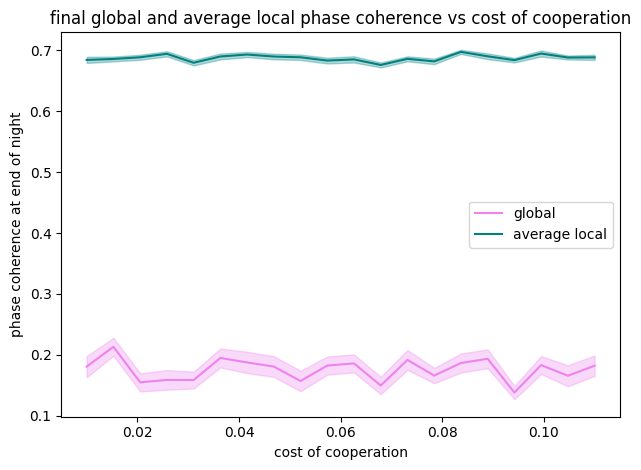

In [4]:
#plot to get variation of final phase coherence with cost, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
nm = int((rootN ** 2) * filledprop)  # number of male fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
coopprop = 0.5  # proportion of cooperators
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
cost_values = np.linspace(0.01, 0.11, 20)  # range of costs from 0.1 to 1.0
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for cost in cost_values:
    final_cohs_per_cost = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_cost = []


    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_cost.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_cost.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_cost)
    std_error_final_coh = np.std(final_cohs_per_cost) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_cost)
    std_error_final_loccoh = np.std(final_loccohs_per_cost) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(cost_values, mean_final_cohs, label='global', color='violet')
plt.fill_between(cost_values, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(cost_values, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(cost_values, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('cost of cooperation')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs cost of cooperation')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

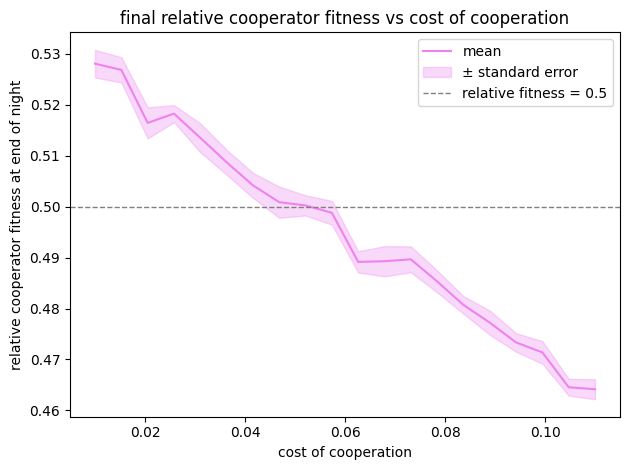

In [11]:
#plot to get variation of final relcoop with cost, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
nm = int((rootN ** 2) * filledprop)  # number of male fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
coopprop = 0.5  # proportion of cooperators
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
cost_values = np.linspace(0.01, 0.11, 20)  # range of costs from 0.1 to 1.0
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for cost in cost_values:
    final_rels_per_cost = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_cost.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_cost)
    std_error_final_rel = np.std(final_rels_per_cost) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(cost_values, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(cost_values, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('cost of cooperation')
plt.ylabel('relative cooperator fitness at end of night')
plt.title('final relative cooperator fitness vs cost of cooperation')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

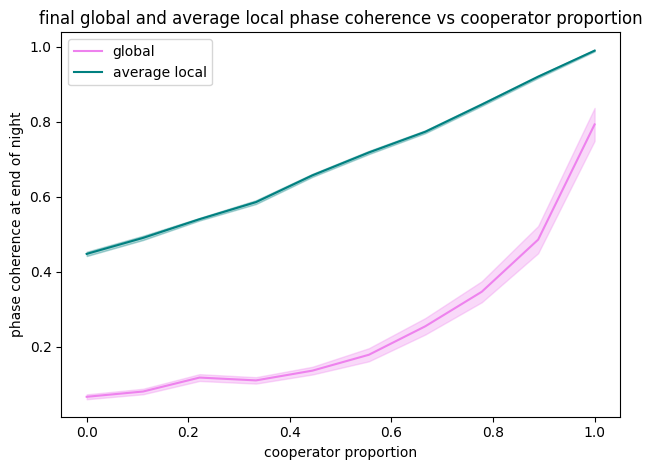

In [10]:
#plot to get variation of final phase coherence with cooperator proportion, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
nm = int((rootN ** 2) * filledprop)  # number of male fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
cost = 0.02  # proportion of cooperators
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
coopprops = np.linspace(0, 1, 10) #range of coopprops for 0 to 1
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for coopprop in coopprops:
    final_cohs_per_coopprop = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_coopprop = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_coopprop.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_coopprop.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_coopprop)
    std_error_final_coh = np.std(final_cohs_per_coopprop) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_coopprop)
    std_error_final_loccoh = np.std(final_loccohs_per_coopprop) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(coopprops, mean_final_cohs, label='global', color='violet')
plt.fill_between(coopprops, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(coopprops, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(coopprops, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('cooperator proportion')
plt.ylabel('phase coherence at end of night' )
plt.title('final global and average local phase coherence vs cooperator proportion')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

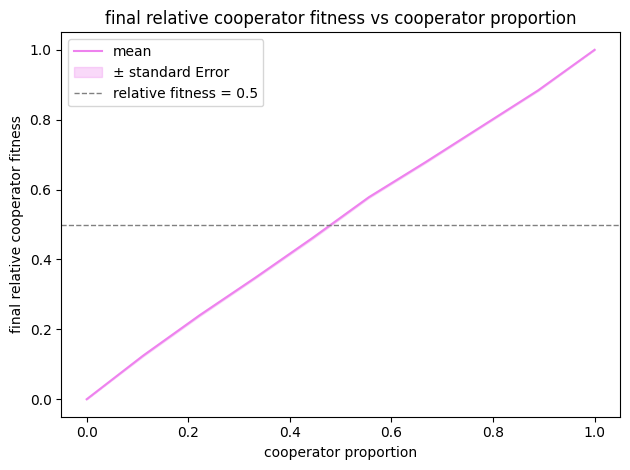

In [13]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
nm = int((rootN ** 2) * filledprop)  # number of male fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
cost = 0.02  # proportion of cooperators
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
coopprops = np.linspace(0, 1, 10) #range of coopprops for 0 to 1
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for coopprop in coopprops:
    final_rels_per_coopprop = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_coopprop.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_coopprop)
    std_error_final_rel = np.std(final_rels_per_coopprop) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(coopprops, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(coopprops, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard Error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('cooperator proportion')
plt.ylabel('final relative cooperator fitness')
plt.title('final relative cooperator fitness vs cooperator proportion')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

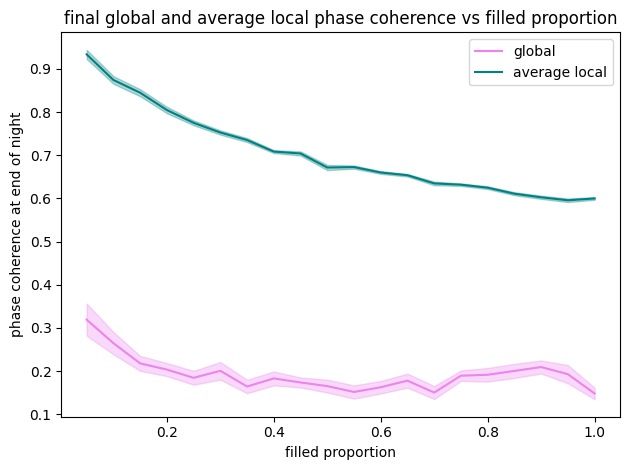

In [14]:
#plot to get variation of final phase coherence with filled proportion, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
coopprop = 0.5  # proportion of the region filled by fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
cost = 0.02  # proportion of cooperators
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
filledprops = np.linspace(0.05, 1, 20)
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for filledprop in filledprops:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_filledprop = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_filledprop = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_filledprop.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_filledprop.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_filledprop)
    std_error_final_coh = np.std(final_cohs_per_filledprop) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_filledprop)
    std_error_final_loccoh = np.std(final_loccohs_per_filledprop) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(filledprops, mean_final_cohs, label='global', color='violet')
plt.fill_between(filledprops, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(filledprops, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(filledprops, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('filled proportion')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs filled proportion')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

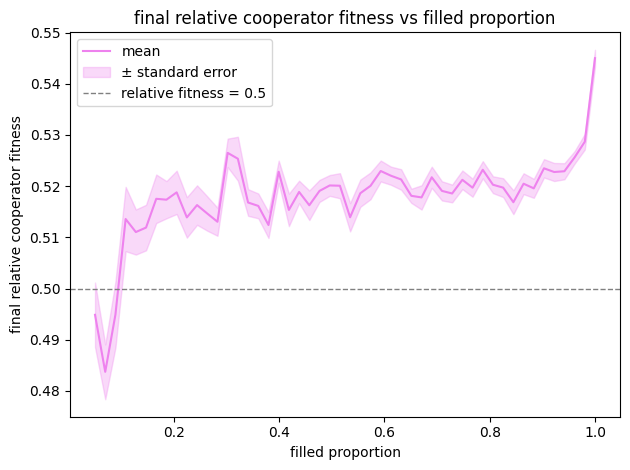

In [16]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
coopprop = 0.5  # proportion of cooperators
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
cost = 0.02  #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
filledprops = np.linspace(0.05, 1, 50) #range of filledprop from 0.05 to 1 (0 has been excluded since there wouldn't be any fireflies)
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for filledprop in filledprops:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_rels_per_filledprop = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_filledprop.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_filledprop)
    std_error_final_rel = np.std(final_rels_per_filledprop) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(filledprops, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(filledprops, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('filled proportion')
plt.ylabel('final relative cooperator fitness')
plt.title('final relative cooperator fitness vs filled proportion')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

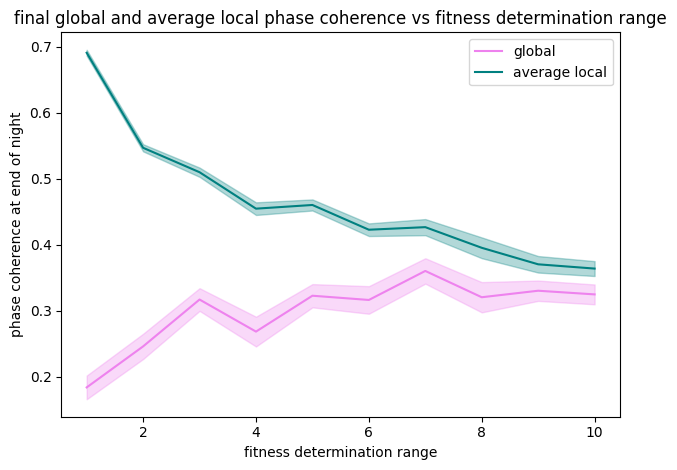

In [17]:
#plot to get variation of final phase coherence with payoff determination range, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
coopprop = 0.5  # proportion of the region filled by fireflies
repeats = 200  # number of iterations over one night
filledprop = 0.5

# Initial setup for firefly positions and phases
cost = 0.02  # proportion of cooperators
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness

# Range of costs to analyze
rangs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] #payoff determination range options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for rang in rangs:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_rang = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_rang = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_rang.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_rang.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_rang)
    std_error_final_coh = np.std(final_cohs_per_rang) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_rang)
    std_error_final_loccoh = np.std(final_loccohs_per_rang) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(rangs, mean_final_cohs, label='global', color='violet')
plt.fill_between(rangs, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(rangs, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(rangs, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('fitness determination range')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs fitness determination range')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

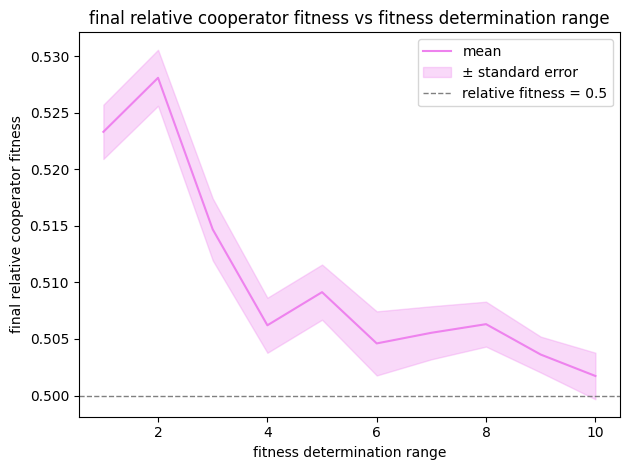

In [18]:
#plot to get variation of final relcoop with fitness determination range, movement rule 1
rootN = 20  #number of rows and columns (square lattice)
coopprop = 0.5  #proportion of cooperators
filledprop = 0.5 #proportion of area filled
repeats = 200  #number of iterations over one night
nm = int((rootN ** 2) * filledprop)  #number of male fireflies

# Initial setup for firefly positions and phases
cost = 0.02  #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness

# Range of costs to analyze
rangs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for rang in rangs:
    final_rels_per_rang = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_rang.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_rang)
    std_error_final_rel = np.std(final_rels_per_rang) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(rangs, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(rangs, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('fitness determination range')
plt.ylabel('final relative cooperator fitness')
plt.title('final relative cooperator fitness vs fitness determination range')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

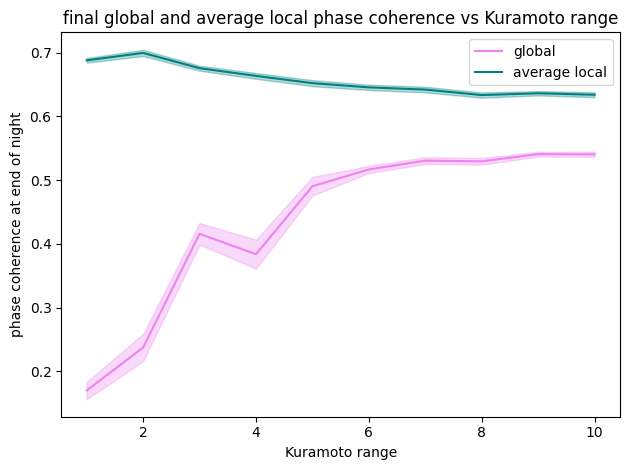

In [19]:
#plot to get variation of final phase coherence with Kuramoto range, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
coopprop = 0.5  # proportion of the region filled by fireflies
repeats = 200  # number of iterations over one night
filledprop = 0.5

# Initial setup for firefly positions and phases
cost = 0.02  # proportion of cooperators
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1

rs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] #payoff determination range options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for r in rs:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_r = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_r = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_r.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_r.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_r)
    std_error_final_coh = np.std(final_cohs_per_r) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_r)
    std_error_final_loccoh = np.std(final_loccohs_per_r) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(rs, mean_final_cohs, label='global', color='violet')
plt.fill_between(rs, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(rs, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(rs, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('Kuramoto range')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs Kuramoto range')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

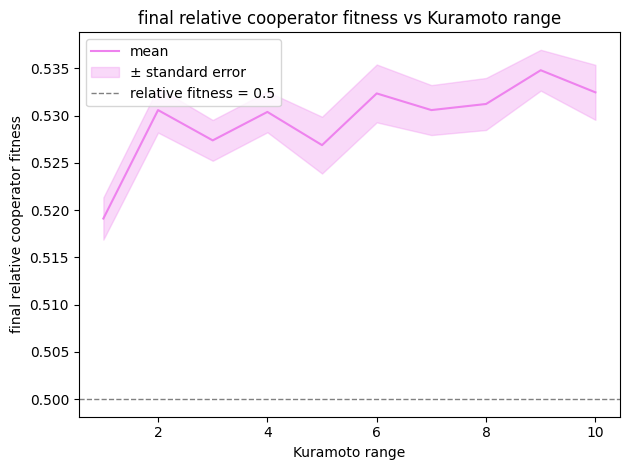

In [20]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  #number of rows and columns (square lattice)
coopprop = 0.5  #proportion of cooperators
filledprop = 0.5 #proportion of area filled
repeats = 200  #number of iterations over one night
nm = int((rootN ** 2) * filledprop)  #number of male fireflies

# Initial setup for firefly positions and phases
cost = 0.02  #cost of cooperation
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
rs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for r in rs:
    final_rels_per_r = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_r.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_r)
    std_error_final_rel = np.std(final_rels_per_r) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(rs, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(rs, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('Kuramoto range')
plt.ylabel('final relative cooperator fitness')
plt.title('final relative cooperator fitness vs Kuramoto range')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

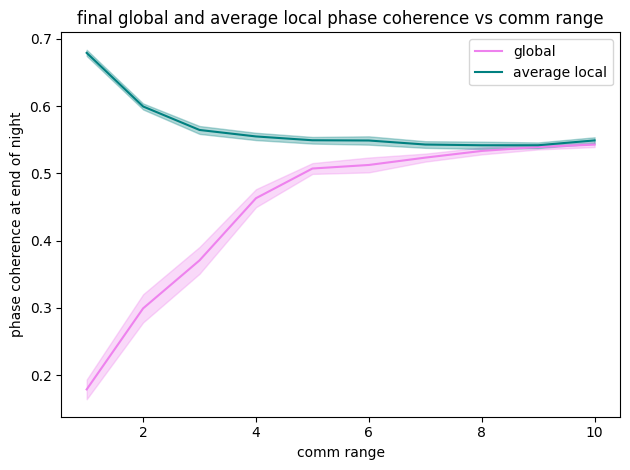

In [21]:
#plot to get variation of final phase coherence with Kuramoto range, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
coopprop = 0.5  # proportion of the region filled by fireflies
repeats = 200  # number of iterations over one night
filledprop = 0.5

# Initial setup for firefly positions and phases
cost = 0.1  # proportion of cooperators
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness

rs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] #payoff determination range options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for r in rs:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    rang = r
    final_cohs_per_r = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_r = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_r.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_r.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_r)
    std_error_final_coh = np.std(final_cohs_per_r) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_r)
    std_error_final_loccoh = np.std(final_loccohs_per_r) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(rs, mean_final_cohs, label='global', color='violet')
plt.fill_between(rs, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(rs, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(rs, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('comm range')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs comm range')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

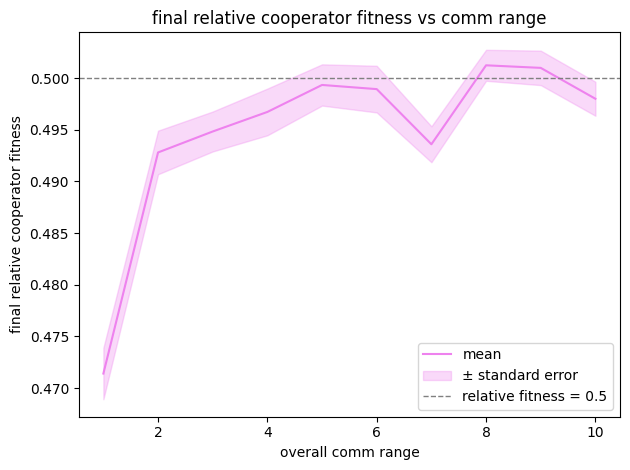

In [22]:
#plot to get variation of final relcoop with both equal ranges, movement rule 1
rootN = 20  #number of rows and columns (square lattice)
coopprop = 0.5  #proportion of cooperators
filledprop = 0.5 #proportion of area filled
repeats = 200  #number of iterations over one night
nm = int((rootN ** 2) * filledprop)  #number of male fireflies

# Initial setup for firefly positions and phases
cost = 0.1  #cost of cooperation
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness

# Range of costs to analyze
rs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for r in rs:
    rang = r
    final_rels_per_r = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_r.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_r)
    std_error_final_rel = np.std(final_rels_per_r) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(rs, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(rs, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('overall comm range')
plt.ylabel('final relative cooperator fitness')
plt.title('final relative cooperator fitness vs comm range')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

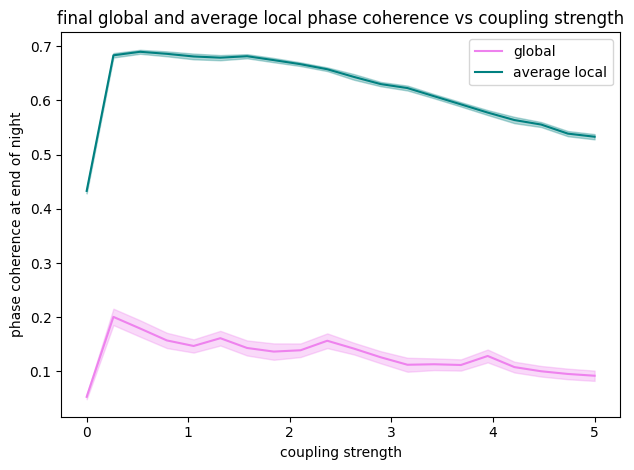

In [23]:
#plot to get variation of final phase coherence with Kuramoto coupling strength, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
coopprop = 0.5  # proportion of the region filled by fireflies
repeats = 200  # number of iterations over one night
filledprop = 0.5

# Initial setup for firefly positions and phases
cost = 0.02  # proportion of cooperators
r = 1
rang = 1
k = 1000 #prob move steepness

Ks = np.linspace(0, 5, 20) #coupling strength options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for K in Ks:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_K = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_K = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_K.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_K.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_K)
    std_error_final_coh = np.std(final_cohs_per_K) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_K)
    std_error_final_loccoh = np.std(final_loccohs_per_K) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(Ks, mean_final_cohs, label='global', color='violet')
plt.fill_between(Ks, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(Ks, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(Ks, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('coupling strength')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs coupling strength')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

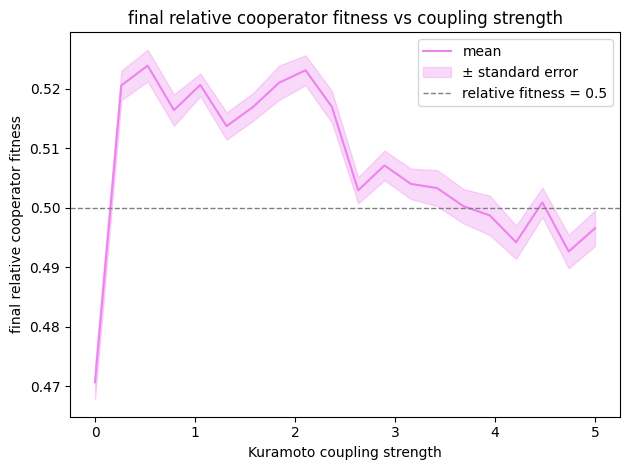

In [24]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  #number of rows and columns (square lattice)
coopprop = 0.5  #proportion of cooperators
filledprop = 0.5 #proportion of area filled
repeats = 200  #number of iterations over one night
nm = int((rootN ** 2) * filledprop)  #number of male fireflies

# Initial setup for firefly positions and phases
cost = 0.02  #cost of cooperation
r = 1 #Kuramoto range
k = 1000 #prob move steepness
rang = 1 #payoff determination range

# Range of costs to analyze
Ks = np.linspace(0, 5, 20) #Kuramoto coupling options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for K in Ks:
    final_rels_per_K = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_K.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_K)
    std_error_final_rel = np.std(final_rels_per_K) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(Ks, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(Ks, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('Kuramoto coupling strength')
plt.ylabel('final relative cooperator fitness')
plt.title('final relative cooperator fitness vs coupling strength')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

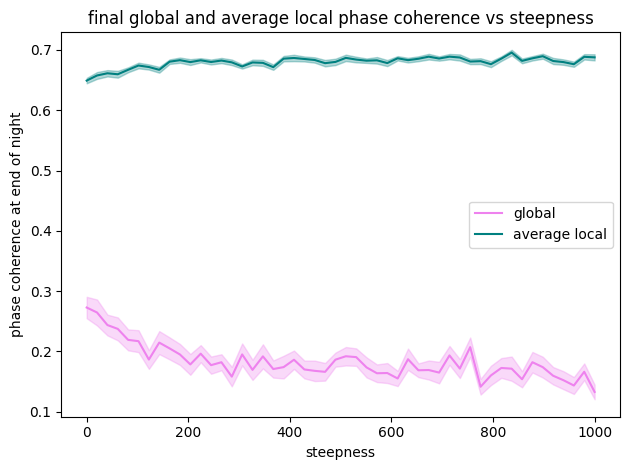

In [25]:
#plot to get variation of final phase coherence with steepness, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
coopprop = 0.5  # proportion of the region filled by fireflies
repeats = 200  # number of iterations over one night
filledprop = 0.5

# Initial setup for firefly positions and phases
cost = 0.1  # proportion of cooperators
r = 1
rang = 1
K = 0.5

ks = np.linspace(0, 1000, 50) #steepness options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for k in ks:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_k = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_k = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_k.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_k.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_k)
    std_error_final_coh = np.std(final_cohs_per_k) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_k)
    std_error_final_loccoh = np.std(final_loccohs_per_k) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(ks, mean_final_cohs, label='global', color='violet')
plt.fill_between(ks, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(ks, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(ks, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('steepness')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs steepness')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

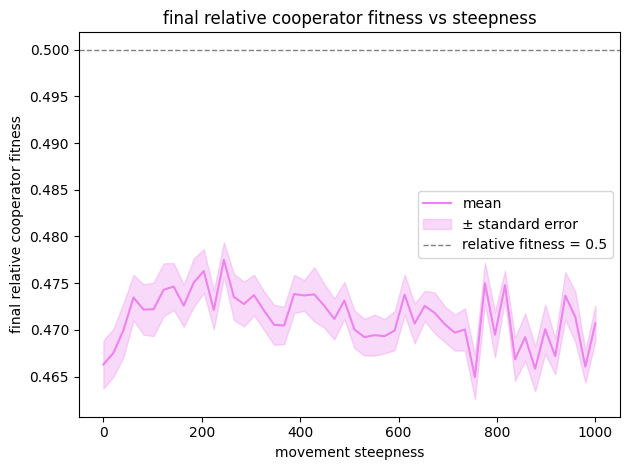

In [26]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  #number of rows and columns (square lattice)
coopprop = 0.5  #proportion of cooperators
filledprop = 0.5 #proportion of area filled
repeats = 200  #number of iterations over one night
nm = int((rootN ** 2) * filledprop)  #number of male fireflies

# Initial setup for firefly positions and phases
cost = 0.1  #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #coupling strength
rang = 1 #payoff determination range

# Range of costs to analyze
ks = np.linspace(0, 1000, 50) #steepness options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for k in ks:
    final_rels_per_k = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])  # standard deviation of final phases
        final_rels_per_k.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_k)
    std_error_final_rel = np.std(final_rels_per_k) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(ks, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(ks, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('movement steepness')
plt.ylabel('final relative cooperator fitness')
plt.title('final relative cooperator fitness vs steepness')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

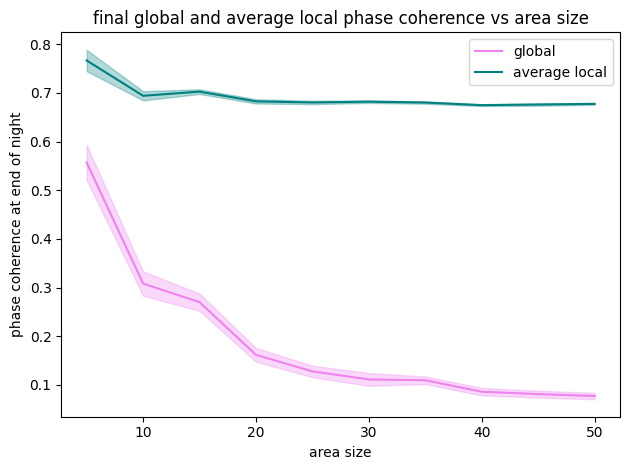

In [3]:
#plot to get variation of final phase coherence with steepness, movement rule 1
coopprop = 0.5  # proportion of the region filled by fireflies
repeats = 200  # number of iterations over one night
filledprop = 0.5

# Initial setup for firefly positions and phases
cost = 0.02  # proportion of cooperators
r = 1
rang = 1
K = 0.5
k = 1000

rootNs = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for rootN in rootNs:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_rootN = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_rootN = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_rootN.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_rootN.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_rootN)
    std_error_final_coh = np.std(final_cohs_per_rootN) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_rootN)
    std_error_final_loccoh = np.std(final_loccohs_per_rootN) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(rootNs, mean_final_cohs, label='global', color='violet')
plt.fill_between(rootNs, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(rootNs, mean_final_loccohs, label='average local', color='teal')
plt.fill_between(rootNs, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('area size')
plt.ylabel('phase coherence at end of night')
plt.title('final global and average local phase coherence vs area size')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

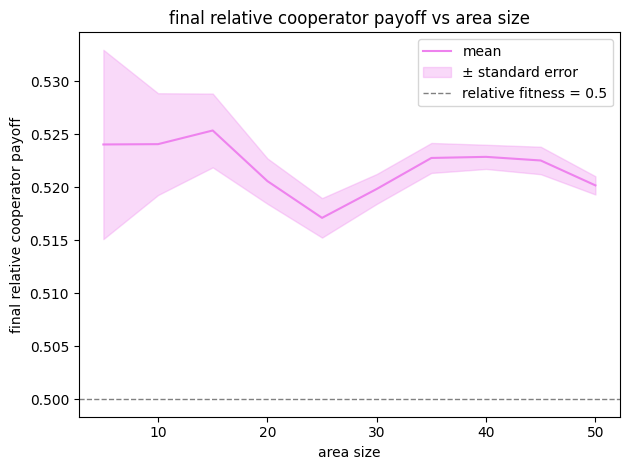

In [4]:
#plot to get variation of final relcoop with area size, movement rule 1
coopprop = 0.5  #proportion of cooperators
filledprop = 0.5 #proportion of area filled
repeats = 200  #number of iterations over one night

# Initial setup for firefly positions and phases
cost = 0.02  #cost of cooperation
r = 1 #Kuramoto range
K = 0.5 #coupling strength
k = 1000 #steepness
rang = 1 #payoff determination range

# Range of costs to analyze
rootNs = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for rootN in rootNs:
    nm = int((rootN ** 2) * filledprop)  #number of male fireflies
    final_rels_per_rootN = []  # to store final std devs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])
        final_rels_per_rootN.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_rootN)
    std_error_final_rel = np.std(final_rels_per_rootN) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(rootNs, mean_final_rels, label='mean', color='violet')

# Fill between upper and lower bounds
plt.fill_between(rootNs, lower_bound, upper_bound, color='violet', alpha=0.3, label='± standard error')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='relative fitness = 0.5')

# Labels and title
plt.xlabel('area size')
plt.ylabel('final relative cooperator payoff')
plt.title('final relative cooperator payoff vs area size')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

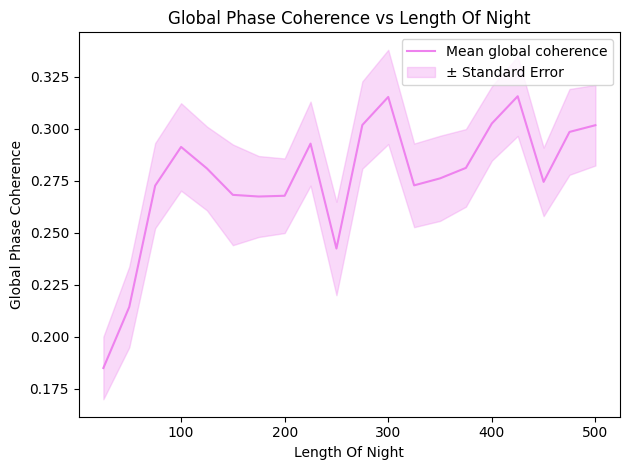

In [29]:
#plot to get variation of final phase coherence with length of night, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
coopprop = 0.5 #proportion of cooperators
rang = 1 #payoff determination range
r = 1 #Kuramoto coupling
k = 3 #probability steepness

# Initial setup for firefly positions and phases
repeatslist = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450, 475, 500] #night length options

# Range of costs to analyze
cost = 0.1
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []

for repeats in repeatslist:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_repeats = []  # to store final cohs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_repeats.append(final_phase_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_repeats)
    std_error_final_coh = np.std(final_cohs_per_repeats) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

# Plot the mean line
plt.plot(repeatslist, mean_final_cohs, label='Mean global coherence', color='violet')

# Fill between upper and lower bounds
plt.fill_between(repeatslist, lower_bound, upper_bound, color='violet', alpha=0.3, label='± Standard Error')

# Labels and title
plt.xlabel('Length Of Night')
plt.ylabel('Global Phase Coherence')
plt.title('Global Phase Coherence vs Length Of Night')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


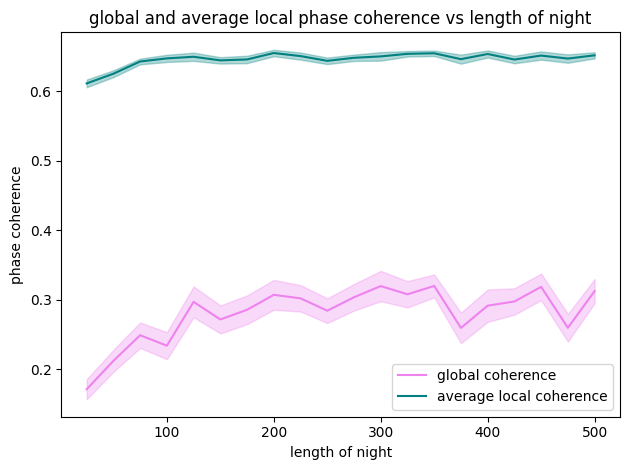

In [16]:
#plot to get variation of final phase coherence with length of night, movement rule 1
rootN = 20
coopprop = 0.5  # proportion of the region filled by fireflies
filledprop = 0.5

# Initial setup for firefly positions and phases
cost = 0.1  # proportion of cooperators
r = 1
rang = 1
K = 0.5
k = 3

repeatslist = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450, 475, 500] #night length options
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_cohs = []
std_error_final_cohs = []
mean_final_loccohs = []
std_error_final_loccohs = []

for repeats in repeatslist:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_cohs_per_repeats = []  # to store final std devs for all trials of a particular cost
    final_loccohs_per_repeats = []

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_phase_coh = globcoh(phase3d[:, :, -1])  # standard deviation of final phases
        final_cohs_per_repeats.append(final_phase_coh)

        final_local_coh = avgloccoh(phase3d[:, :, -1], rang)  # get local coherence
        final_loccohs_per_repeats.append(final_local_coh)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_coh = np.mean(final_cohs_per_repeats)
    std_error_final_coh = np.std(final_cohs_per_repeats) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_cohs.append(mean_final_coh)
    std_error_final_cohs.append(std_error_final_coh)

    mean_final_loccoh = np.mean(final_loccohs_per_repeats)
    std_error_final_loccoh = np.std(final_loccohs_per_repeats) / np.sqrt(num_trials)

    mean_final_loccohs.append(mean_final_loccoh)
    std_error_final_loccohs.append(std_error_final_loccoh)

# Convert lists to arrays if needed
mean_final_cohs = np.array(mean_final_cohs)
std_error_final_cohs = np.array(std_error_final_cohs)

mean_final_loccohs = np.array(mean_final_loccohs)
std_error_final_loccohs = np.array(std_error_final_loccohs)

# Create upper and lower bounds
upper_bound = mean_final_cohs + std_error_final_cohs
lower_bound = mean_final_cohs - std_error_final_cohs

upper_bound_loc = mean_final_loccohs + std_error_final_loccohs
lower_bound_loc = mean_final_loccohs - std_error_final_loccohs

# Plot the mean line
plt.plot(repeatslist, mean_final_cohs, label='global coherence', color='violet')
plt.fill_between(repeatslist, lower_bound, upper_bound, color='violet', alpha=0.3)

plt.plot(repeatslist, mean_final_loccohs, label='average local coherence', color='teal')
plt.fill_between(repeatslist, lower_bound_loc, upper_bound_loc, color='teal', alpha=0.3)

# Labels and title
plt.xlabel('length of night')
plt.ylabel('phase coherence')
plt.title('global and average local phase coherence vs length of night')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

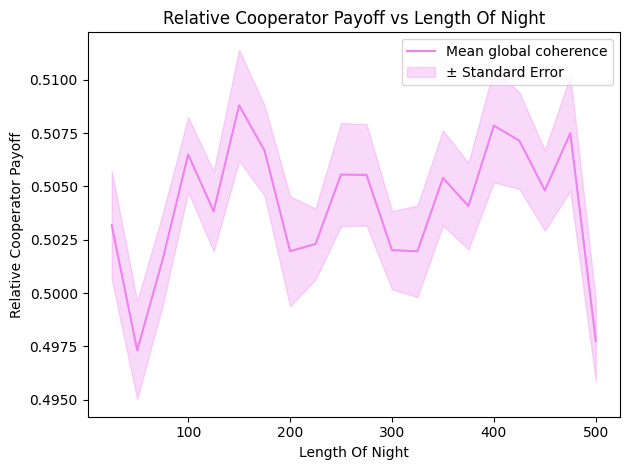

In [30]:
#plot to get variation of final relcoop with length of night, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
coopprop = 0.5 #proportion of cooperators
rang = 1 #payoff determination range
r = 1 #Kuramoto coupling
k = 3 #probability steepness

# Initial setup for firefly positions and phases
repeatslist = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450, 475, 500] #night length options

# Range of costs to analyze
cost = 0.1
num_trials = 30  # number of trials for each cost

# Arrays to store results
mean_final_rels = []
std_error_final_rels = []

for repeats in repeatslist:
    nm = int((rootN ** 2) * filledprop)  # number of male fireflies
    final_rels_per_repeats = []  # to store final cohs for all trials of a particular cost

    for trial in range(num_trials):
        # Reset initial setup for each trial
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
        firststrat = altstrat(firstpos, coopprop)  # initial strategy array
        firstpay = payoff_arr(firstphase, firststrat, rang)  # initial payoff array

        # 3D arrays for storing phase and strategy over time
        phase3d = np.zeros((rootN, rootN, repeats + 1))
        strat3d = np.zeros((rootN, rootN, repeats + 1))

        # Initialize first time point
        phase3d[:, :, 0] = firstphase
        strat3d[:, :, 0] = firststrat

        firstphase = movphase = firstphase
        firststrat = movstrat = firststrat

        for i in range(repeats):
            # Update phase and strategy
            secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
            secondpay = payoff_arr(secondphase, firststrat, rang)  # Payoff update with current cost
            movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update

            # Store updates in 3D arrays
            phase3d[:, :, i + 1] = movphase
            strat3d[:, :, i + 1] = movstrat

            # Update first phase, strategy, and payoff for the next iteration
            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        # Compute the standard deviation of the final phase array for this trial
        final_rel_coop = relcooppay(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang), strat3d[:, :, -1])
        final_rels_per_repeats.append(final_rel_coop)

    # Calculate mean and standard error of the final standard deviations for this cost
    mean_final_rel = np.mean(final_rels_per_repeats)
    std_error_final_rel = np.std(final_rels_per_repeats) / np.sqrt(num_trials)  # standard error

    # Store the results
    mean_final_rels.append(mean_final_rel)
    std_error_final_rels.append(std_error_final_rel)

# Convert lists to arrays if needed
mean_final_rels = np.array(mean_final_rels)
std_error_final_rels = np.array(std_error_final_rels)

# Create upper and lower bounds
upper_bound = mean_final_rels + std_error_final_rels
lower_bound = mean_final_rels - std_error_final_rels

# Plot the mean line
plt.plot(repeatslist, mean_final_rels, label='Mean global coherence', color='violet')

# Fill between upper and lower bounds
plt.fill_between(repeatslist, lower_bound, upper_bound, color='violet', alpha=0.3, label='± Standard Error')

# Labels and title
plt.xlabel('Length Of Night')
plt.ylabel('Relative Cooperator Payoff')
plt.title('Relative Cooperator Payoff vs Length Of Night')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
